In [29]:
# Remove unwanted warning
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Data Management
import pandas as pd
import numpy as np
import polars as pl
import pyarrow as pa
from pandas_datareader.data import DataReader
from ta import add_all_ta_features

# Feature Engineering
from sklearn.preprocessing import StandardScaler

# Cointegration and Statistics
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm
from functools import partial

# Machine Learning
from sklearn.cluster import KMeans
from sklearn import metrics
from kneed import KneeLocator

# Reporting
import matplotlib.pyplot as plt

# Operating System
import os
import gc
import multiprocessing as mp

In [30]:
# Global Variables
CSV_FILENAME = "stocks.csv"
PARQET_FILENAME = "stocks.parquet"
WORKING_DIR = "data/"
FEATURES = ["gvkey"]
load_coint_pairs = False

### Data Extraction

In [31]:
if not os.path.exists(os.path.join(
        WORKING_DIR, CSV_FILENAME
    )):
    # read sample data
    file_path = os.path.join(
        WORKING_DIR, "ret_sample.csv"
    )
    data = pl.read_csv(file_path)
    data = data.filter(pl.col("excntry").is_in(["CAN","USA"]))
    # write the North American csv
    data.write_csv(os.path.join(WORKING_DIR, CSV_FILENAME))

if not os.path.exists(os.path.join(
    WORKING_DIR, PARQET_FILENAME
    )):
    # write the parquet file (more memory efficient)
    data = pd.read_csv(os.path.join(WORKING_DIR, CSV_FILENAME), dtype={4: str})
    data.to_parquet(PARQET_FILENAME, index=False, compression="snappy")

# read the parquet file
data = pd.read_parquet(os.path.join(WORKING_DIR, PARQET_FILENAME))




In [32]:
# Display basic information
print("DataFrame Head:")
data.head()
print(data.shape)

DataFrame Head:
(1398807, 159)


In [33]:
# this will give us all the companies we want by removing ones from the same company
print(data.shape)
df_no_duplicate = data.drop_duplicates(subset=["id"], keep='first')
print(df_no_duplicate.shape)
df_no_duplicate = df_no_duplicate.drop_duplicates(subset=["gvkey"], keep="first")
df_ids = df_no_duplicate["id"]
print(df_ids.shape)
del df_no_duplicate
gc.collect()
type(df_ids.values)

(1398807, 159)
(16739, 159)
(13661,)


numpy.ndarray

In [34]:
df_used_comps = data[data["id"].isin(df_ids.values)]
del data
gc.collect()
df_used_comps = df_used_comps[df_used_comps["date"] < 20150000]

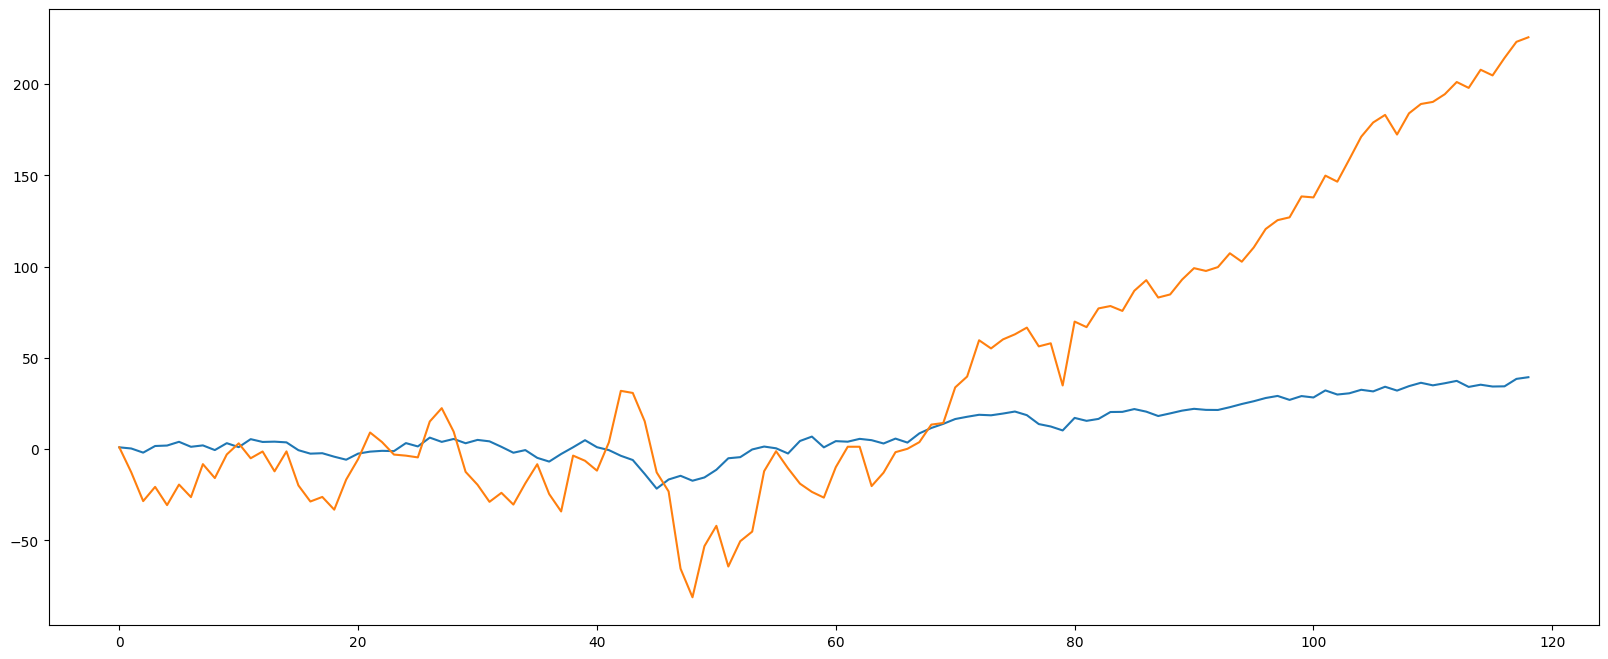

In [35]:
series1 = df_used_comps[df_used_comps["id"] == "crsp_45751"]
series2 = df_used_comps[df_used_comps["id"] == "crsp_60871"]
series2_values = series2["stock_ret"].cumsum().values / series2["stock_ret"].iloc[0].item()
series1_values = series1["stock_ret"].cumsum().values / series1["stock_ret"].iloc[0].item()
plt.figure(1, figsize=(20,8))
plt.plot(series2_values)
plt.plot(series1_values)
plt.show()

In [36]:
# get a df for just the returns for all companies
# pivot so that gvkey are columns, date are rows, stock_ret are values
df_ret = df_used_comps.pivot(index="date", columns="id", values="stock_ret")
df_ret = df_ret.sort_index()
df_ret.fillna(value=0, inplace=True)
df_ret = df_ret.cumsum()
# df_ret.dropna(inplace=True)
df_ret.head()

id,comp_001081_01C,comp_001096_01C,comp_001117_02,comp_001186_01C,comp_001243_01C,comp_001262_01C,comp_001263_04C,comp_001715_01C,comp_001828_01C,comp_002055_01C,...,crsp_93426,crsp_93427,crsp_93428,crsp_93429,crsp_93430,crsp_93432,crsp_93433,crsp_93434,crsp_93435,crsp_93436
date,,,,,,,,,,,,,,,,,,,,,
20050201,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20050202,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20050207,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20050208,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20050209,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
# the features that we need for K-Means Clustering
k_means_features = ["id", "excntry", "beta_60m", "betadown_252d", "ivol_capm_252d", "corr_1260d",
                    "dolvol_126d", "bidaskhl_21d", "market_equity", "be_me", "ebitda_mev", "ni_be"]
df_kmeans_raw = df_used_comps[k_means_features]
df_kmeans_raw

,id,excntry,beta_60m,betadown_252d,ivol_capm_252d,corr_1260d,dolvol_126d,bidaskhl_21d,market_equity,be_me,ebitda_mev,ni_be
0,comp_001081_01C,CAN,0.650452,0.779315,0.017210,0.387781,1.547222e+07,0.004671,2398.152284,1.254719,0.075173,-0.020637
1,comp_001096_01C,CAN,0.423608,0.445162,0.015467,0.245148,1.708334e+05,0.008006,301.116426,1.512289,0.094516,-0.009665
2,comp_001117_02,USA,1.636192,1.073565,0.049833,0.124188,5.934347e+04,0.018585,32.808300,0.329155,0.104697,0.192055
3,comp_001186_01C,CAN,0.220041,1.326215,0.015602,0.174888,4.953975e+06,0.004598,1099.753789,0.454720,0.058404,0.069303
4,comp_001243_01C,CAN,0.822356,1.259809,0.012803,0.474511,4.715816e+07,0.005936,14740.873131,0.806940,0.112443,0.060446
...,...,...,...,...,...,...,...,...,...,...,...,...
731527,crsp_93428,USA,1.287472,0.676067,0.025175,0.343495,6.546325e+06,0.007958,776.924770,0.279866,0.005099,-0.042905
731528,crsp_93429,USA,0.550775,0.765164,0.012866,0.435073,3.622505e+07,0.006971,5056.344077,0.054860,0.066961,0.646992
731529,crsp_93433,USA,2.470811,0.901662,0.048974,0.313479,5.889188e+04,0.023577,5.662254,0.008830,NaN,-487.020000
731530,crsp_93434,USA,0.056181,1.152274,0.035907,0.172292,4.811824e+05,0.024368,42.905121,1.203143,0.037132,0.007226


In [38]:
# find the mean of each feature for each company
numeric_profiles = df_kmeans_raw.groupby("id").mean(numeric_only=True)

# the country is also relevant for finding out if 2 stocks are related, so we one-hot encode the country
categorical_profiles = df_kmeans_raw.groupby("id").agg({
    "excntry": "first",
}).reset_index()
categorical_dummies = pd.get_dummies(categorical_profiles, columns=["excntry"], prefix="country")
df_kmeans = numeric_profiles.merge(categorical_dummies, on='id')

In [39]:
# clean up data we don't need to save memory
del df_kmeans_raw
gc.collect()
df_kmeans

,id,beta_60m,betadown_252d,ivol_capm_252d,corr_1260d,dolvol_126d,bidaskhl_21d,market_equity,be_me,ebitda_mev,ni_be,country_CAN,country_USA
0,comp_001081_01C,0.871460,1.220010,0.025249,0.422152,9.457032e+06,0.009828,1482.619754,1.992183,0.107540,-0.039722,1,0
1,comp_001096_01C,0.998435,0.640172,0.018128,0.470540,2.596834e+05,0.004855,766.087964,1.499063,0.069519,0.071129,1,0
2,comp_001117_02,1.639312,-0.092419,0.041624,0.108037,7.994780e+04,0.011586,32.050986,0.472977,0.096488,0.351784,0,1
3,comp_001186_01C,0.900235,1.429606,0.024792,0.510581,3.828259e+07,0.008479,6819.428825,0.434357,0.038821,0.029312,1,0
4,comp_001243_01C,1.238969,1.348182,0.017193,0.635446,7.321841e+07,0.006005,19212.344891,0.688135,0.124815,0.059652,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9732,crsp_93432,NaN,-0.263154,0.031014,NaN,4.109071e+05,0.012865,85.610649,1.721234,2.897833,0.249219,0,1
9733,crsp_93433,2.563137,1.435955,0.056548,0.333073,4.807046e+06,0.021997,173.406000,1.079014,-0.041936,-79.664588,0,1
9734,crsp_93434,-0.015549,0.705201,0.032312,0.162187,3.224584e+05,0.014800,51.162037,0.529407,-0.003012,-0.001588,0,1
9735,crsp_93435,NaN,0.791421,0.060557,NaN,1.057282e+06,0.023489,77.101692,1.842304,1.279383,0.231481,0,1


In [40]:
# Remove any companies with NaN values
df_kmeans.dropna(inplace=True)
print("has NaN values:", df_kmeans.isnull().values.any())
df_kmeans

has NaN values: False


,id,beta_60m,betadown_252d,ivol_capm_252d,corr_1260d,dolvol_126d,bidaskhl_21d,market_equity,be_me,ebitda_mev,ni_be,country_CAN,country_USA
0,comp_001081_01C,0.871460,1.220010,0.025249,0.422152,9.457032e+06,0.009828,1482.619754,1.992183,0.107540,-0.039722,1,0
1,comp_001096_01C,0.998435,0.640172,0.018128,0.470540,2.596834e+05,0.004855,766.087964,1.499063,0.069519,0.071129,1,0
2,comp_001117_02,1.639312,-0.092419,0.041624,0.108037,7.994780e+04,0.011586,32.050986,0.472977,0.096488,0.351784,0,1
3,comp_001186_01C,0.900235,1.429606,0.024792,0.510581,3.828259e+07,0.008479,6819.428825,0.434357,0.038821,0.029312,1,0
4,comp_001243_01C,1.238969,1.348182,0.017193,0.635446,7.321841e+07,0.006005,19212.344891,0.688135,0.124815,0.059652,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9729,crsp_93428,1.280755,0.551290,0.039515,0.341977,1.707230e+07,0.011081,788.676427,0.171083,0.024988,0.079224,0,1
9730,crsp_93429,0.523453,0.744000,0.013627,0.448848,2.098400e+07,0.006000,2809.869117,0.200878,0.180858,0.502726,0,1
9733,crsp_93433,2.563137,1.435955,0.056548,0.333073,4.807046e+06,0.021997,173.406000,1.079014,-0.041936,-79.664588,0,1
9734,crsp_93434,-0.015549,0.705201,0.032312,0.162187,3.224584e+05,0.014800,51.162037,0.529407,-0.003012,-0.001588,0,1


In [41]:
# Check for any infinite values
dfobj = df_kmeans.isin([np.inf, -np.inf])
count = np.isinf(dfobj).values.sum()
print("Infinite Values:", count)

# Garbage collection to save memory
del dfobj
gc.collect()

Infinite Values: 0


0

In [42]:
df_kmeans.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7516 entries, 0 to 9736
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              7516 non-null   object 
 1   beta_60m        7516 non-null   float64
 2   betadown_252d   7516 non-null   float64
 3   ivol_capm_252d  7516 non-null   float64
 4   corr_1260d      7516 non-null   float64
 5   dolvol_126d     7516 non-null   float64
 6   bidaskhl_21d    7516 non-null   float64
 7   market_equity   7516 non-null   float64
 8   be_me           7516 non-null   float64
 9   ebitda_mev      7516 non-null   float64
 10  ni_be           7516 non-null   float64
 11  country_CAN     7516 non-null   uint8  
 12  country_USA     7516 non-null   uint8  
dtypes: float64(10), object(1), uint8(2)
memory usage: 719.3+ KB


### Feature Scaling

In [43]:
non_scalable = df_kmeans[["id", "country_USA", "country_CAN"]].copy()
scalable = df_kmeans.drop(columns=["id", "country_USA", "country_CAN"])

scaler = StandardScaler()
scaler = scaler.fit_transform(scalable)
df_kmeans_scaled = pd.DataFrame(scaler, columns=scalable.columns, index=scalable.index)
df_kmeans_scaled = pd.concat([df_kmeans_scaled, non_scalable], axis=1)
df_kmeans_scaled = df_kmeans_scaled.set_index('id')

del df_kmeans
gc.collect()

df_kmeans_scaled

,beta_60m,betadown_252d,ivol_capm_252d,corr_1260d,dolvol_126d,bidaskhl_21d,market_equity,be_me,ebitda_mev,ni_be,country_USA,country_CAN
id,,,,,,,,,,,,
comp_001081_01C,-0.507848,0.455530,-0.412064,0.355016,-0.153269,-0.354679,-0.094375,0.077830,0.013337,0.021418,0,1
comp_001096_01C,-0.335828,-0.634420,-0.830388,0.626422,-0.289911,-0.670814,-0.152404,0.034136,0.009726,0.026030,0,1
comp_001117_02,0.532403,-2.011505,0.549914,-1.406824,-0.292582,-0.242885,-0.211851,-0.056783,0.012287,0.037707,1,0
comp_001186_01C,-0.468865,0.849517,-0.438888,0.851009,0.274986,-0.440402,0.337835,-0.060205,0.006811,0.024290,0,1
comp_001243_01C,-0.009963,0.696460,-0.885298,1.551366,0.794020,-0.597734,1.341495,-0.037719,0.014978,0.025553,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
crsp_93428,0.046647,-0.801495,0.426022,-0.094676,-0.040130,-0.275048,-0.150575,-0.083534,0.005497,0.026367,1,0
crsp_93429,-0.979311,-0.439249,-1.094754,0.504756,0.017985,-0.598004,0.013115,-0.080893,0.020300,0.043988,1,0
crsp_93433,1.783959,0.861452,1.426622,-0.144618,-0.222352,0.418935,-0.200404,-0.003084,-0.000859,-3.291532,1,0


### K-Means Clustering

In [44]:
# Find the optpimum number of clusters
X = df_kmeans_scaled.copy()
K = range(1, 20)
distortions = []
for k in K:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)
    distortions.append(kmeans.inertia_)

kl = KneeLocator(K,distortions, curve="convex", direction="decreasing")
c = kl.elbow
print("Optimum Clusters:", c)

Optimum Clusters: 8


In [45]:
# Fit K-Means Model
k_means = KMeans(n_clusters=c)
k_means.fit(X)
prediction = k_means.predict(df_kmeans_scaled)

In [46]:
# Return the series
clustered_series = pd.Series(index=X.index, data=k_means.labels_.flatten())
clustered_series_all = pd.Series(index=X.index, data=k_means.labels_.flatten())
clustered_series = clustered_series[clustered_series != -1]
clustered_series.tail()

id
crsp_93428    3
crsp_93429    6
crsp_93433    0
crsp_93434    3
crsp_93436    6
dtype: int32

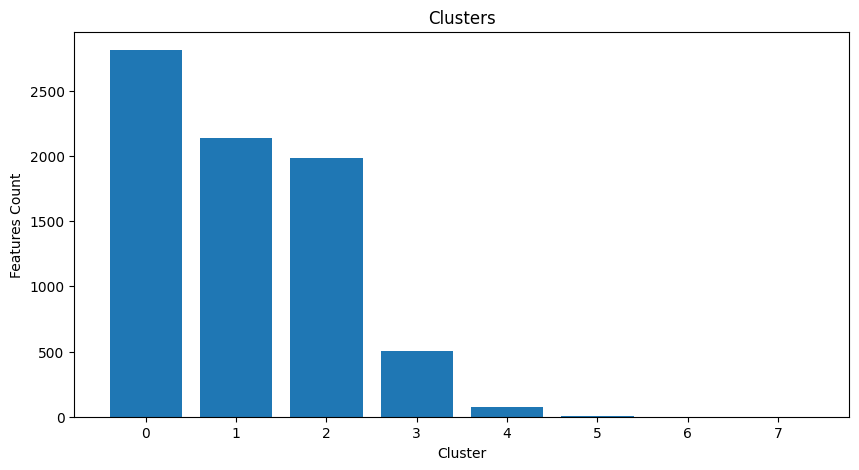

In [47]:
plt.figure(figsize=(10,5))
plt.bar(range(len(clustered_series.value_counts())), clustered_series.value_counts())
plt.title("Clusters")
plt.xlabel("Cluster")
plt.ylabel("Features Count")
plt.show()

In [48]:
clustered_series.value_counts()

6    2813
3    2136
0    1986
1     506
5      71
4       2
2       1
7       1
dtype: int64

In [49]:
# Remvoe Items if Preferred
print(clustered_series.value_counts())
clusters_clean = clustered_series
print("Feature Number Previous: ", len(clustered_series))
print("Feature Number Current: ", len(clusters_clean))
clusters_clean

6    2813
3    2136
0    1986
1     506
5      71
4       2
2       1
7       1
dtype: int64
Feature Number Previous:  7516
Feature Number Current:  7516


id
comp_001081_01C    6
comp_001096_01C    6
comp_001117_02     3
comp_001186_01C    6
comp_001243_01C    6
                  ..
crsp_93428         3
crsp_93429         6
crsp_93433         0
crsp_93434         3
crsp_93436         6
Length: 7516, dtype: int32

### Calculate Cointegration

In [50]:
foo = 1

In [57]:
def calculate_cointegration(series_1, series_2):
    coint_res = coint(series_1, series_2)
    coint_t, p_value, crit_values = coint_res

    # regression to estimate hedge ratio
    X = sm.add_constant(series_2)
    model = sm.OLS(series_1, X).fit()
    hedge_ratio = model.params[1]

    # flag if cointegrated
    coint_flag = 1 if (coint_t < crit_values[1]) and (p_value < 0.05) else 0
    return coint_flag, hedge_ratio

In [58]:
def test_pair_cointegration(pair_data, df_ret):
    """Helper function for parallel processing"""
    base_asset, compare_asset, label = pair_data
    series_1 = df_ret[base_asset].values.astype(float)
    series_2 = df_ret[compare_asset].values.astype(float)
    
    coint_flag, *_ = calculate_cointegration(series_1, series_2)
    if coint_flag == 1:
        print("we are adding")
        return {
            "base asset": base_asset,
            "compare asset": compare_asset,
            "label": label
        }
    return None

In [59]:
# Strategy 5: Combined Approach (Recommended)
def optimize_cointegration_testing_combined(clusters_clean, df_ret, 
                                           corr_threshold=0.6, 
                                           max_pairs_per_cluster=100,
                                           n_processes=None):
    """
    Combine correlation filtering with parallel processing
    """
    all_pairs_to_test = []
    
    for label in clusters_clean.unique():
        cluster_assets = clusters_clean[clusters_clean == label].index.tolist()
        if len(cluster_assets) <= 1:
            continue
            
        # Pre-filter by correlation
        cluster_data = df_ret[cluster_assets]
        corr_matrix = cluster_data.corr()
        
        high_corr_pairs = []
        for i, asset1 in enumerate(cluster_assets):
            for j, asset2 in enumerate(cluster_assets[i+1:], i+1):
                corr_val = abs(corr_matrix.loc[asset1, asset2])
                if corr_val > corr_threshold:
                    high_corr_pairs.append((asset1, asset2, corr_val, label))
        
        # Sort by correlation and limit
        high_corr_pairs.sort(key=lambda x: x[2], reverse=True)
        high_corr_pairs = high_corr_pairs[:max_pairs_per_cluster]
        
        all_pairs_to_test.extend([(pair[0], pair[1], pair[3]) for pair in high_corr_pairs])
    
    print(f"After correlation filtering: {len(all_pairs_to_test)} pairs to test")
    return all_pairs_to_test
    
    # # Parallel processing
    # if n_processes is None:
    #     n_processes = mp.cpu_count() - 1
    
    # with mp.Pool(processes=n_processes) as pool:
    #     test_func = partial(test_pair_cointegration, df_ret=df_ret)
    #     results = pool.map(test_func, all_pairs_to_test)
    
    # cointegrated_pairs = [result for result in results if result is not None]
    
    # return pd.DataFrame(cointegrated_pairs).sort_values(by="label")

In [60]:
if not load_coint_pairs:
    # Choose your strategy:
    
    # Fast but less comprehensive
    # df_coint = optimize_cointegration_testing_v1(clusters_clean, df_ret, sample_size=5000)
    
    # Correlation-based filtering
    # df_coint = optimize_cointegration_testing_v2(clusters_clean, df_ret, corr_threshold=0.7, max_pairs_per_cluster=100)
    
    # Representative selection
    # df_coint = optimize_cointegration_testing_v3(clusters_clean, df_ret, n_representatives=50)
    
    # Recommended: Combined approach
    df_coint = optimize_cointegration_testing_combined(
        clusters_clean, df_ret, 
        corr_threshold=0.6, 
        max_pairs_per_cluster=100,
        n_processes=4  # Adjust based on your CPU
    )

After correlation filtering: 500 pairs to test


In [61]:
# Loop through and calculate cointegrate pairs
cointegrated_pairs = []
for tup in df_coint:
    series_1 = df_ret[tup[0]].values.astype(float)
    series_2 = df_ret[tup[1]].values.astype(float)
    coint_flag, _ = calculate_cointegration(series_1, series_2)
    if coint_flag == 1:
        # print("adding")
        cointegrated_pairs.append({
            "base asset": tup[0],
            "compare asset": tup[1],
            "label": tup[2]})
    df_coint_new = pd.DataFrame(cointegrated_pairs).sort_values(by="label")
    # df_coint.to_csv(file_name_coint)                              

/home/mahan-maalekian/anaconda3/envs/MLTRADE/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:1721: CollinearityWarning: y0 and y1 are (almost) perfectly colinear.Cointegration test is not reliable in this case.
  warnings.warn(
/home/mahan-maalekian/anaconda3/envs/MLTRADE/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:1721: CollinearityWarning: y0 and y1 are (almost) perfectly colinear.Cointegration test is not reliable in this case.
  warnings.warn(
/home/mahan-maalekian/anaconda3/envs/MLTRADE/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:1721: CollinearityWarning: y0 and y1 are (almost) perfectly colinear.Cointegration test is not reliable in this case.
  warnings.warn(
/home/mahan-maalekian/anaconda3/envs/MLTRADE/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:1721: CollinearityWarning: y0 and y1 are (almost) perfectly colinear.Cointegration test is not reliable in this case.
  warnings.warn(
/home/mahan-maalekian/anaconda3/envs/MLTRADE/lib/pyt

In [62]:
df_coint_csv = df_coint_new.iloc[:, 0:2]
df_coint_csv.to_csv("data/cointegrated-pairs.csv", index=False)
df_coint_csv

,base asset,compare asset
203,crsp_82549,crsp_88952
223,crsp_87401,crsp_88651
224,crsp_88441,crsp_88952
225,crsp_46295,crsp_79850
226,crsp_66130,crsp_79850
...,...,...
63,comp_006135_01C,comp_066319_02C
64,comp_183683_01C,crsp_92614
65,crsp_43553,crsp_89002
45,crsp_77106,crsp_89389


In [ ]:
# Loop through and calculate cointegrate pairs
tested_pairs = []
cointegrated_pairs = []
if not load_coint_pairs:
    for base_asset in clusters_clean.index:
        base_label = clusters_clean[base_asset]
        for compare_asset in clusters_clean.index:
            compare_label = clusters_clean[compare_asset]
            test_pair = str(base_asset) + str(compare_asset)
            test_pair = ''.join(sorted(test_pair))
            is_tested = test_pair in tested_pairs
            tested_pairs.append(test_pair)
            if compare_asset != base_asset and base_label == compare_label and not is_tested:

                series_1 = df_ret[base_asset].values.astype(float)
                series_2 = df_ret[compare_asset].values.astype(float)
                print(series_1)
                print(series_2)
                coint_flag, _ = calculate_cointegration(series_1, series_2)
                if coint_flag == 1:
                    print("adding")
                    cointegrated_pairs.append({
                        "base asset": base_asset,
                        "compare asset": compare_asset,
                        "label": base_label})
    df_coint = pd.DataFrame(cointegrated_pairs).sort_values(by="label")
    # df_coint.to_csv(file_name_coint)                              

In [ ]:
df_coint

In [ ]:
series1 = df_ret["crsp_60871"].values
series2 = df_ret["crsp_78987"].values
xpoints = df_ret.index.values
plt.figure(1, figsize=(20,8))
plt.plot(xpoints, series1)
plt.plot(xpoints, series2)
plt.show()

In [ ]:
df_ret